In [35]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, roc_auc_score, precision_score, recall_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [36]:
tf.__version__

'2.20.0'

In [37]:
from google.colab import files

uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling (2).csv


In [38]:
df=pd.read_csv("Churn_Modelling.csv")

In [39]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [40]:
if 'RowNumber' in df.columns:
  df=df.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [41]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])

X = df.drop('Exited', axis = 1)
y = df['Exited']

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
X_test

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
9394,597,1,0,35,8,131101.04,1,1,1,192852.67
898,523,0,0,40,2,102967.41,1,1,0,128702.10
2398,706,2,0,42,8,95386.82,1,1,1,75732.25
5906,788,0,1,32,4,112079.58,1,0,0,89368.59
2343,706,1,1,38,5,163034.82,2,1,1,135662.17
...,...,...,...,...,...,...,...,...,...,...
1037,625,0,0,24,1,0.00,2,1,1,180969.55
2899,586,0,0,35,7,0.00,2,1,0,70760.69
9549,578,2,1,36,1,157267.95,2,1,0,141533.19
2740,650,1,1,34,4,142393.11,1,1,1,11276.48


In [43]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [44]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [45]:
ann = tf.keras.models.Sequential()

In [46]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [47]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [57]:
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [49]:
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [50]:
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
monitor='val_loss',
factor=0.2,
patience=10,
min_lr=0.0001
)

In [58]:
history = ann.fit(
X_train, y_train,
batch_size=32,
epochs=100,
validation_data=(X_test, y_test))

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8640 - loss: 0.3365 - val_accuracy: 0.8620 - val_loss: 0.3364
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8640 - loss: 0.3364 - val_accuracy: 0.8620 - val_loss: 0.3359
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8620 - loss: 0.3367 - val_accuracy: 0.8620 - val_loss: 0.3360
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8620 - loss: 0.3360 - val_accuracy: 0.8645 - val_loss: 0.3361
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8624 - loss: 0.3359 - val_accuracy: 0.8660 - val_loss: 0.3357
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8621 - loss: 0.3360 - val_accuracy: 0.8590 - val_loss: 0.3387
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8643 - loss: 0.3359 - val_accuracy: 0.8640 - val_loss: 0.3348
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8622 - loss: 0.3359 - val_accu

In [59]:
history1= ann.fit(
X_train, y_train,
batch_size=32,
epochs=100,
validation_data=(X_test, y_test),
callbacks=[early_stopping, reduce_lr],
verbose=1)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8656 - loss: 0.3321 - val_accuracy: 0.8590 - val_loss: 0.3372 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8644 - loss: 0.3322 - val_accuracy: 0.8620 - val_loss: 0.3361 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8643 - loss: 0.3322 - val_accuracy: 0.8610 - val_loss: 0.3331 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8643 - loss: 0.3317 - val_accuracy: 0.8610 - val_loss: 0.3351 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8635 - loss: 0.3324 - val_accuracy: 0.8610 - val_loss: 0.3351 - learning_rate: 0.0010
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8649 - loss: 0.3318 - val_accuracy: 0.8605 - val_loss: 0.3330 - learning_rate: 0.0010
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8639 - loss: 0.

In [60]:
early_stopping =tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,restore_best_weights=True
)
reduce_lr=tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,patience=10,min_lr=0.0001
)

In [61]:
print(ann.predict(sc.transform([[1, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])) > 0.5)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
[[False]]


In [62]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1595
           1       0.00      0.00      0.00       405

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [63]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)


[[1595    0]
 [ 405    0]]


0.7975

In [64]:
print("\nEvaluating the model...")
train_loss, train_acc = ann.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = ann.evaluate(X_test, y_test, verbose=0)
# For training set
y_train_pred = ann.predict(X_train)
y_train_pred_class = (y_train_pred > 0.5)
train_precision = precision_score(y_train, y_train_pred_class)
train_recall = recall_score(y_train, y_train_pred_class)
train_auc = roc_auc_score(y_train, y_train_pred)
# For test set
y_test_pred = ann.predict(X_test)
y_test_pred_class = (y_test_pred > 0.5)
test_precision = precision_score(y_test, y_test_pred_class)
test_recall = recall_score(y_test, y_test_pred_class)
test_auc = roc_auc_score(y_test, y_test_pred)
print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")


Evaluating the model...
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Training Accuracy: 0.8656
Test Accuracy: 0.8605
Test Precision: 0.0000
Test Recall: 0.0000
Test AUC: 0.1334


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


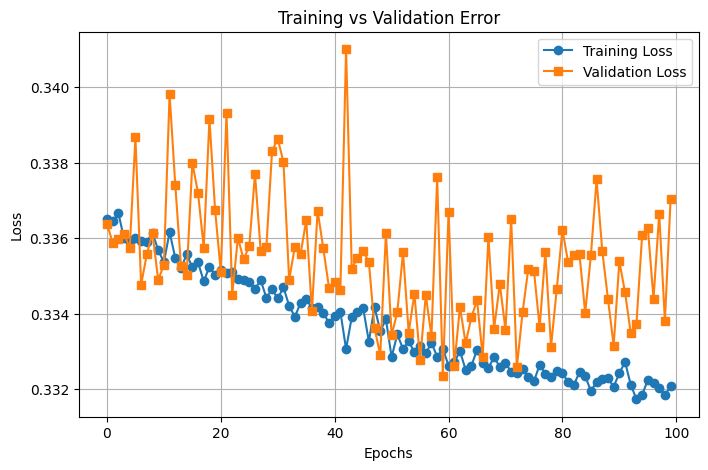

In [65]:
import matplotlib.pyplot as plt
# Plot training vs validation error (loss)
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title("Training vs Validation Error")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

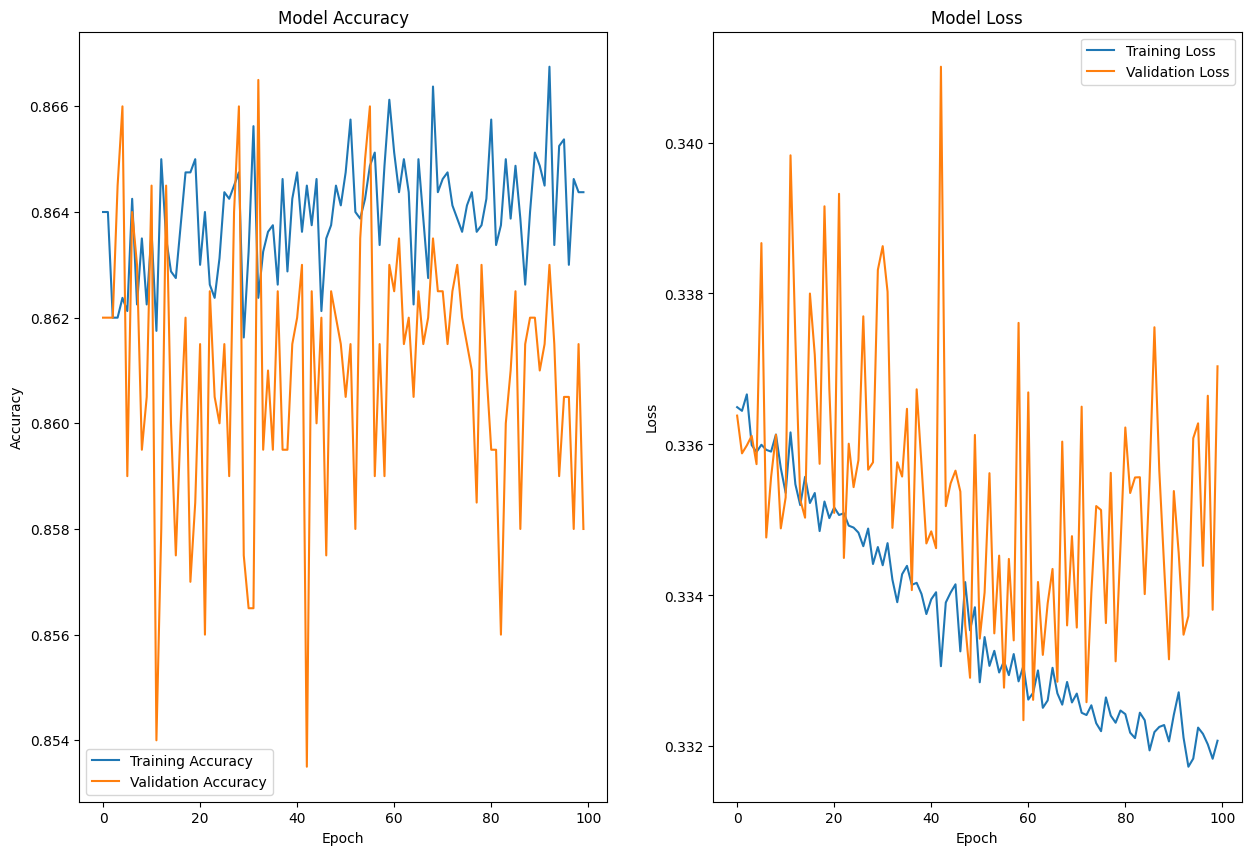

In [66]:

import matplotlib.pyplot as plt
# Plot training history
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
plot_training_history(history)

In [67]:
ann.save('churn_ann_model.h5')

print("Model saved successfully")

Model saved successfully


In [68]:
import joblib

# Save preprocessing objects
joblib.dump(sc, 'scaler.pkl')
joblib.dump(le, 'label_encoder_gender.pkl')

print("All preprocessing files saved")

All preprocessing files saved
